In [1]:
from datetime import datetime, UTC
from urllib.parse import urlencode
from urllib.request import urlopen
from urllib.error import HTTPError, URLError
import json

BASE_URL = "https://api.kraken.com"


def to_datetime(timestamp: int) -> str:
    return datetime.fromtimestamp(timestamp, UTC).strftime(
        "%Y-%m-%d %H:%M:%S UTC"
    )


def get_ohlc(pair="BTC/USD", interval=1440, since=None):
    """
    Fetch OHLC candles from Kraken.

    Intervals:
        1      = 1 minute
        5      = 5 minutes
        15     = 15 minutes
        30     = 30 minutes
        60     = 1 hour
        240    = 4 hours
        1440   = 1 day
        10080  = 1 week
        21600  = 15 days
    """

    params = {
        "pair": pair,
        "interval": interval,
    }

    if since is not None:
        params["since"] = since

    url = f"{BASE_URL}/0/public/OHLC?{urlencode(params)}"

    try:
        with urlopen(url) as response:
            payload = json.load(response)

        if payload["error"]:
            raise RuntimeError(payload["error"])

        result = payload["result"]

        # Pair key is dynamic
        pair_key = next(k for k in result.keys() if k != "last")

        candles = []

        for candle in result[pair_key]:
            candles.append({
                "timestamp": candle[0],
                "datetime": to_datetime(candle[0]),
                "open": float(candle[1]),
                "high": float(candle[2]),
                "low": float(candle[3]),
                "close": float(candle[4]),
                "vwap": float(candle[5]),
                "volume": float(candle[6]),
                "trades": int(candle[7]),
            })

        return candles

    except HTTPError as e:
        raise RuntimeError(f"HTTP error: {e.code}") from e

    except URLError as e:
        raise RuntimeError(f"Connection error: {e.reason}") from e


if __name__ == "__main__":
    daily_btc = get_ohlc(
        pair="BTC/USD",
        interval=1440,   # daily candles
    )

    data = json.dumps(daily_btc, indent=2)

In [2]:
import pandas as pd

# create dataframe
df = pd.DataFrame(json.loads(data))

# convert datetime column to pandas datetime
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.head())

    timestamp                  datetime     open     high      low    close  \
0  1717545600 2024-06-05 00:00:00+00:00  70558.7  71709.0  70378.9  71103.6   
1  1717632000 2024-06-06 00:00:00+00:00  71116.3  71596.5  70100.0  70752.1   
2  1717718400 2024-06-07 00:00:00+00:00  70752.1  71900.0  68409.0  69317.0   
3  1717804800 2024-06-08 00:00:00+00:00  69317.1  69511.2  69138.0  69291.5   
4  1717891200 2024-06-09 00:00:00+00:00  69291.5  69809.8  69155.3  69649.9   

      vwap       volume  trades  
0  71096.3  2163.807485   25310  
1  70986.6  1460.013522   19241  
2  70490.2  2531.872632   32830  
3  69345.9   601.462207   12379  
4  69520.8   421.248417   12724  


In [3]:
df.drop(["timestamp", "vwap", "trades"], axis = 1, inplace = True)

df.head()

,datetime,open,high,low,close,volume
0,2024-06-05 00:00:00+00:00,70558.7,71709.0,70378.9,71103.6,2163.807485
1,2024-06-06 00:00:00+00:00,71116.3,71596.5,70100.0,70752.1,1460.013522
2,2024-06-07 00:00:00+00:00,70752.1,71900.0,68409.0,69317.0,2531.872632
3,2024-06-08 00:00:00+00:00,69317.1,69511.2,69138.0,69291.5,601.462207
4,2024-06-09 00:00:00+00:00,69291.5,69809.8,69155.3,69649.9,421.248417


In [4]:
#df_2025 = df[df["datetime"].dt.year >= 2025]

#df_2025

In [5]:
df_filtered = df[
    (df["datetime"] >= "2025-01-01") &
    (df["datetime"] <= "2026-04-30")
].reset_index(drop=True)

df_filtered

,datetime,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154


In [6]:
df = df_filtered.copy()

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

In [7]:
df

,datetime,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154


In [8]:
df["candle_body"] = df["close"] - df["open"]
'''
df["body"] = abs(df["close"] - df["open"])

df["upper_wick"] = (
    df["high"] - df[["close", "open"]].max(axis=1)
)

df["lower_wick"] = (
    df[["close", "open"]].min(axis=1) - df["low"]
)

df["body_ratio"] = (
    df["body"] / (df["high"] - df["low"])
)
'''

'\ndf["body"] = abs(df["close"] - df["open"])\n\ndf["upper_wick"] = (\n    df["high"] - df[["close", "open"]].max(axis=1)\n)\n\ndf["lower_wick"] = (\n    df[["close", "open"]].min(axis=1) - df["low"]\n)\n\ndf["body_ratio"] = (\n    df["body"] / (df["high"] - df["low"])\n)\n'

In [9]:
#df["volatility"] = (
#    df["close"].pct_change().rolling(10).std()
#)

#df

In [10]:
import pandas as pd
import numpy as np

from ta.momentum import RSIIndicator
from ta.trend import MACD, EMAIndicator
from ta.volatility import AverageTrueRange

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

In [11]:
df["ret1"] = df["close"].pct_change(1)
df["ret3"] = df["close"].pct_change(3)
df["ret7"] = df["close"].pct_change(7)
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,NaN,NaN,NaN
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,0.025687,NaN,NaN
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,0.013490,NaN,NaN
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,0.000997,0.040560,NaN
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,0.000991,0.015505,NaN
...,...,...,...,...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154,-581.6,-0.007619,-0.036915,-0.031376


In [12]:
df["rsi"] = RSIIndicator(
    close=df["close"],
    window=14
).rsi()

In [13]:
#macd = MACD(close=df["close"])

#df["macd"] = macd.macd()
#df["macd_signal"] = macd.macd_signal()
#df["macd_diff"] = macd.macd_diff()

In [14]:
df["ema20"] = EMAIndicator(
    close=df["close"],
    window=20
).ema_indicator()

#df["ema50"] = EMAIndicator(
#    close=df["close"],
#    window=50
#).ema_indicator()

In [15]:
df["ema20_dist"] = (
    (df["close"] - df["ema20"]) / df["ema20"]
)

#df["ema50_dist"] = (
#    (df["close"] - df["ema50"]) / df["ema50"]
#)

In [16]:
'''
atr = AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["atr"] = atr.average_true_range()
'''

'\natr = AverageTrueRange(\n    high=df["high"],\n    low=df["low"],\n    close=df["close"],\n    window=14\n)\n\ndf["atr"] = atr.average_true_range()\n'

In [17]:
df["future_return"] = (
    (df["close"].shift(-1) - df["close"]) / df["close"]
)

df["target"] = (
    df["candle_body"] > 0
).astype(int)

In [18]:
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,rsi,ema20,ema20_dist,future_return,target
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,NaN,NaN,NaN,NaN,NaN,NaN,0.025687,1
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,0.025687,NaN,NaN,NaN,NaN,NaN,0.013490,1
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,0.013490,NaN,NaN,NaN,NaN,NaN,0.000997,1
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,0.000997,0.040560,NaN,NaN,NaN,NaN,0.000991,1
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,0.000991,0.015505,NaN,NaN,NaN,NaN,0.039833,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,65.148517,75118.817082,0.047059,-0.016262,1
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,59.871659,75333.663074,0.027093,-0.013477,0
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,55.896652,75428.733258,0.011974,-0.007619,0
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154,-581.6,-0.007619,-0.036915,-0.031376,53.753128,75459.358662,0.003856,0.007428,0


In [19]:
df["target"] = df["target"].shift(-1)
df = df.dropna().reset_index(drop=True)
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,rsi,ema20,ema20_dist,future_return,target
0,2025-01-20 00:00:00+00:00,101191.0,109112.0,99500.0,102162.8,6144.710114,971.8,0.009603,-0.018513,0.081235,62.042960,98494.274386,0.037246,0.039153,1.0
1,2025-01-21 00:00:00+00:00,102142.1,107200.0,100114.2,106162.8,2766.178680,4020.7,0.039153,0.017060,0.099448,68.920871,99224.610158,0.069924,-0.023683,0.0
2,2025-01-22 00:00:00+00:00,106162.8,106293.4,103271.3,103648.5,1391.420726,-2514.3,-0.023683,0.024285,0.031365,61.390642,99645.933001,0.040168,0.002621,1.0
3,2025-01-23 00:00:00+00:00,103648.6,106833.2,101281.7,103920.2,4692.190785,271.6,0.002621,0.017202,0.039444,61.875395,100053.006048,0.038651,0.008855,1.0
4,2025-01-24 00:00:00+00:00,103920.2,107080.6,102800.0,104840.4,1795.722536,920.2,0.008855,-0.012456,0.007211,63.544809,100508.948329,0.043095,-0.001290,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,62.752690,74746.713617,0.038822,0.012947,1.0
461,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,65.148517,75118.817082,0.047059,-0.016262,0.0
462,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,59.871659,75333.663074,0.027093,-0.013477,0.0
463,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,55.896652,75428.733258,0.011974,-0.007619,0.0


In [20]:
features_to_lag = [
    "open",
    "high",
    "low",
    "close",
    "candle_body",
    "volume",
    "rsi",
    "ema20_dist",
    #"atr",
    #"ret1", 
    #"ret3",
    #"ret7"
]

In [21]:
lags = 5

for feature in features_to_lag:
    
    for lag in range(1, lags + 1):
        
        df[f"{feature}_lag{lag}"] = (
            df[feature].shift(lag)
        )

In [22]:
df = df.dropna().reset_index(drop=True)

In [23]:
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,...,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,ema20_dist_lag1,ema20_dist_lag2,ema20_dist_lag3,ema20_dist_lag4,ema20_dist_lag5
0,2025-01-25 00:00:00+00:00,104840.4,105194.1,104250.0,104705.2,643.545404,-135.2,-0.001290,0.010195,0.003096,...,63.544809,61.875395,61.390642,68.920871,62.042960,0.043095,0.038651,0.040168,0.069924,0.037246
1,2025-01-26 00:00:00+00:00,104705.3,105380.0,102544.1,102596.5,949.064810,-2108.8,-0.020139,-0.012738,0.013889,...,63.107569,63.544809,61.875395,61.390642,68.920871,0.037624,0.043095,0.038651,0.040168,0.069924
2,2025-01-27 00:00:00+00:00,102596.5,103200.0,97688.7,102133.3,3883.430483,-463.2,-0.004515,-0.025821,-0.000289,...,56.569570,63.107569,63.544809,61.875395,61.390642,0.015110,0.037624,0.043095,0.038651,0.040168
3,2025-01-28 00:00:00+00:00,102133.3,103728.0,100200.0,101299.8,1817.066330,-833.5,-0.008161,-0.032524,-0.045807,...,55.216347,56.569570,63.107569,63.544809,61.875395,0.009515,0.015110,0.037624,0.043095,0.038651
4,2025-01-29 00:00:00+00:00,101299.9,104749.1,101277.6,103708.0,2068.764115,2408.1,0.023773,0.010834,0.000574,...,52.770121,55.216347,56.569570,63.107569,63.544809,0.001155,0.009515,0.015110,0.037624,0.043095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,...,62.289351,65.530718,65.369968,61.489696,60.368487,0.040485,0.056116,0.061312,0.042907,0.040729
456,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,...,62.752690,62.289351,65.530718,65.369968,61.489696,0.038822,0.040485,0.056116,0.061312,0.042907
457,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,...,65.148517,62.752690,62.289351,65.530718,65.369968,0.047059,0.038822,0.040485,0.056116,0.061312
458,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,...,59.871659,65.148517,62.752690,62.289351,65.530718,0.027093,0.047059,0.038822,0.040485,0.056116


In [24]:
df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'candle_body',
       'ret1', 'ret3', 'ret7', 'rsi', 'ema20', 'ema20_dist', 'future_return',
       'target', 'open_lag1', 'open_lag2', 'open_lag3', 'open_lag4',
       'open_lag5', 'high_lag1', 'high_lag2', 'high_lag3', 'high_lag4',
       'high_lag5', 'low_lag1', 'low_lag2', 'low_lag3', 'low_lag4', 'low_lag5',
       'close_lag1', 'close_lag2', 'close_lag3', 'close_lag4', 'close_lag5',
       'candle_body_lag1', 'candle_body_lag2', 'candle_body_lag3',
       'candle_body_lag4', 'candle_body_lag5', 'volume_lag1', 'volume_lag2',
       'volume_lag3', 'volume_lag4', 'volume_lag5', 'rsi_lag1', 'rsi_lag2',
       'rsi_lag3', 'rsi_lag4', 'rsi_lag5', 'ema20_dist_lag1',
       'ema20_dist_lag2', 'ema20_dist_lag3', 'ema20_dist_lag4',
       'ema20_dist_lag5'],
      dtype='str')

In [25]:
excluded_cols = [
    "datetime",
    "future_return",
    "body",
    "target"
]

In [26]:
feature_cols = [
    col for col in df.columns
    if col not in excluded_cols
]

X = df[feature_cols]

y = df["target"]

In [27]:
#split_index = int(len(df) * 0.8)

#X_train = X.iloc[:split_index]
#X_test = X.iloc[split_index:]

#y_train = y.iloc[:split_index]
#y_test = y.iloc[split_index:]

In [28]:
train_df = df[df["datetime"].dt.year == 2025]

# test set -> only 2026
test_df = df[df["datetime"].dt.year == 2026]

# build X and y
X_train = train_df[feature_cols]
y_train = train_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

In [29]:
from sklearn.ensemble import RandomForestClassifier
'''
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
'''

model = XGBClassifier( 
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    eval_metric="logloss" 
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [30]:
predictions = model.predict(X_test)

In [31]:
predictions

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1])

In [32]:
prob = model.predict_proba(X_test)
prob

array([[0.9124573 , 0.08754272],
       [0.7564971 , 0.24350293],
       [0.88400257, 0.11599746],
       [0.87260836, 0.12739162],
       [0.701458  , 0.29854205],
       [0.64479744, 0.35520253],
       [0.20218784, 0.79781216],
       [0.58105206, 0.41894794],
       [0.6968266 , 0.3031734 ],
       [0.249977  , 0.750023  ],
       [0.44291115, 0.55708885],
       [0.43291223, 0.56708777],
       [0.4244318 , 0.5755682 ],
       [0.49207532, 0.5079247 ],
       [0.66646975, 0.33353025],
       [0.68788636, 0.3121136 ],
       [0.5590718 , 0.44092822],
       [0.6655755 , 0.33442447],
       [0.58274186, 0.41725814],
       [0.02705151, 0.9729485 ],
       [0.28057027, 0.71942973],
       [0.4388849 , 0.5611151 ],
       [0.77242845, 0.22757156],
       [0.70038867, 0.29961136],
       [0.61669356, 0.38330644],
       [0.6003777 , 0.39962232],
       [0.28500968, 0.7149903 ],
       [0.48477793, 0.5152221 ],
       [0.45981002, 0.54019   ],
       [0.65187705, 0.34812298],
       [0.

In [33]:
print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    classification_report(y_test, predictions)
)

Accuracy: 0.5462184873949579
              precision    recall  f1-score   support

         0.0       0.60      0.39      0.47        62
         1.0       0.52      0.72      0.60        57

    accuracy                           0.55       119
   macro avg       0.56      0.55      0.54       119
weighted avg       0.56      0.55      0.53       119



In [34]:
df.loc[X_test.index, "prediction"] = predictions

In [35]:
df["position"] = df["prediction"].map({
    1: 1,
    0: -1
})

In [36]:
df["strategy_return"] = (
    df["position"] * df["future_return"]
)

In [37]:
df["strategy_equity"] = (
    1 + df["strategy_return"]
).cumprod()

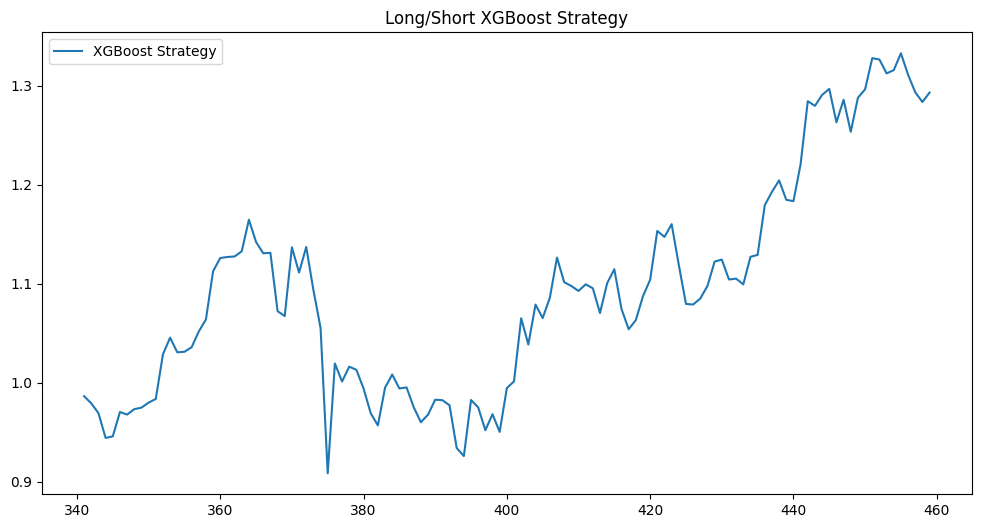

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["strategy_equity"],
    label="XGBoost Strategy"
)

plt.legend()

plt.title(
    "Long/Short XGBoost Strategy"
)

plt.show()

In [39]:
model.feature_importances_

array([0.02109316, 0.01510649, 0.01889282, 0.0252178 , 0.0253664 ,
       0.01750184, 0.01436761, 0.01772715, 0.01554485, 0.02340061,
       0.01609862, 0.02317025, 0.02283338, 0.0130032 , 0.02295799,
       0.0173284 , 0.02154834, 0.02465306, 0.02198226, 0.02713105,
       0.01090456, 0.02145176, 0.02361322, 0.02223106, 0.02048658,
       0.01987008, 0.01730827, 0.01516448, 0.0435073 , 0.01602478,
       0.01600383, 0.01062174, 0.0171929 , 0.01742609, 0.0176395 ,
       0.02307748, 0.0181615 , 0.01597998, 0.01498597, 0.02322728,
       0.01750588, 0.01508882, 0.0230688 , 0.01934083, 0.01526384,
       0.01272714, 0.01533713, 0.01837492, 0.0212012 , 0.01838399,
       0.01515959, 0.01874413], dtype=float32)

In [42]:
# rolling maximum equity
df["equity_peak"] = (
    df["strategy_equity"].cummax()
)

# drawdown
df["drawdown"] = (
    df["strategy_equity"] /
    df["equity_peak"] - 1
)

# maximum drawdown
max_drawdown = df["drawdown"].min()

print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.2198693072129213


In [44]:
# winning trades
gross_profit = df.loc[
    df["strategy_return"] > 0,
    "strategy_return"
].sum()

# losing trades
gross_loss = abs(
    df.loc[
        df["strategy_return"] < 0,
        "strategy_return"
    ].sum()
)

profit_factor = gross_profit / gross_loss

print("Profit Factor:", profit_factor)

Profit Factor: 1.3054059365149646


In [45]:
proba = model.predict_proba(X_test)[:, 1]

In [46]:
# predicted probabilities
proba = model.predict_proba(X_test)[:, 1]

# add probabilities to test dataframe
test_df = test_df.copy()

test_df["proba"] = proba


In [47]:
proba

array([0.08754272, 0.24350293, 0.11599746, 0.12739162, 0.29854205,
       0.35520253, 0.79781216, 0.41894794, 0.3031734 , 0.750023  ,
       0.55708885, 0.56708777, 0.5755682 , 0.5079247 , 0.33353025,
       0.3121136 , 0.44092822, 0.33442447, 0.41725814, 0.9729485 ,
       0.71942973, 0.5611151 , 0.22757156, 0.29961136, 0.38330644,
       0.39962232, 0.7149903 , 0.5152221 , 0.54019   , 0.34812298,
       0.5169368 , 0.64840335, 0.715871  , 0.76633507, 0.8457144 ,
       0.7531938 , 0.66175485, 0.79207283, 0.8632821 , 0.7763562 ,
       0.7722799 , 0.7814273 , 0.656583  , 0.8557419 , 0.617109  ,
       0.88571185, 0.8868988 , 0.5795875 , 0.8005291 , 0.68654895,
       0.59439427, 0.79140896, 0.83793104, 0.87617546, 0.8100853 ,
       0.66129875, 0.7389457 , 0.8403336 , 0.68675476, 0.7240954 ,
       0.34140325, 0.5959939 , 0.64206666, 0.25642556, 0.6275853 ,
       0.48482025, 0.784904  , 0.38120124, 0.18858854, 0.45777106,
       0.66591644, 0.25922096, 0.30934203, 0.64288235, 0.25535

In [58]:
df["trend_regime"] = (
    df["close"] > df["ema20"]
).astype(int)

# default flat
test_df["position"] = 0

# LONGS ONLY ABOVE EMA20
test_df.loc[
    (test_df["proba"] > 0.6), #&
    #(test_df["close"] > test_df["ema20"]), #&
    #(test_df["rsi"] < 30),
    "position"
] = 1

# SHORTS ONLY BELOW EMA20
test_df.loc[
    (test_df["proba"] < 0.4), #&
    #(test_df["close"] < test_df["ema20"]), #&
    #(test_df["rsi"] > 70),
    "position"
] = -1

In [59]:
# default = flat position
#test_df["position"] = 0

# long signal
#test_df.loc[test_df["proba"] > 0.7, "position"] = 1

# short signal
#test_df.loc[test_df["proba"] < 0.3, "position"] = -1

In [60]:
test_df["strategy_return"] = (
    test_df["position"] * test_df["future_return"]
)

In [61]:
test_df["strategy_equity"] = (
    1 + test_df["strategy_return"]
).cumprod()

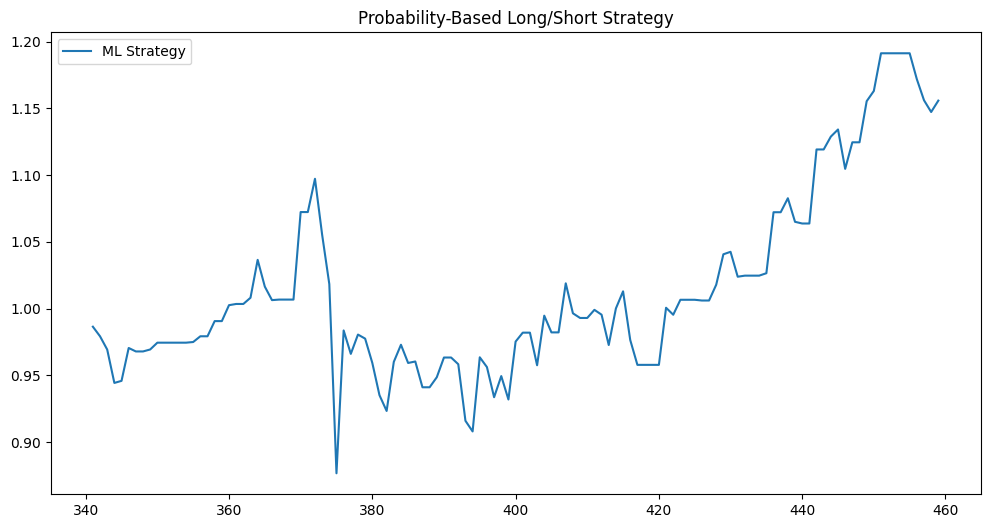

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test_df["strategy_equity"],
    label="ML Strategy"
)

plt.legend()

plt.title("Probability-Based Long/Short Strategy")

plt.show()

In [ ]:
test_df